# 1- metrological raw uk data importing

This code imports the metrological data of the uk using an API and return it as a csv file

After that i have condacted some EDA to explore the data but it wont effect the returned data file

---



## Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
!pip install git+https://github.com/m0rp43us/openmeteopy
!pip install requests-cache retry-requests numpy pandas

  Cloning https://github.com/m0rp43us/openmeteopy to /tmp/pip-req-build-97i24zgj
  Running command git clone --filter=blob:none --quiet https://github.com/m0rp43us/openmeteopy /tmp/pip-req-build-97i24zgj
  Resolved https://github.com/m0rp43us/openmeteopy to commit be76f2deabd7ff5ec3f87ebc983091a367e24117
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.5/811.5 kB 30.9 MB/s eta 0:00:00
  Created wheel for openmeteopy: filename=openmeteopy-0.1.0-py3-none-any.whl size=64551 sha256=68d9266485c6ea91c56701bdf9be5ca586478dbdd41c4f94e94ab5282a50c185
  Stored in directory: /tmp/pip-ephem-wheel-cache-wgkybu5q/wheels/83/d5/e1/5ba45f60b1278b380c594e3c4ab9af559b3f01680764b70bbb
Successfully built openmeteopy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.3 MB/s eta 0:00:00


#Importing Metrological data from API




In [1]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests numpy pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.7/706.7 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.1/394.1 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 58.2 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19


In [2]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 54.7584,
	"longitude": -2.6953,
	"start_date": "1944-01-01",
	"end_date": "2023-12-31",
	"daily": ["temperature_2m_mean", "precipitation_sum", "wind_speed_10m_mean"],
	"timezone": "auto",
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_mean = daily.Variables(0).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(1).ValuesAsNumpy()
daily_wind_speed_10m_mean = daily.Variables(2).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
daily_data["precipitation_sum"] = daily_precipitation_sum
daily_data["wind_speed_10m_mean"] = daily_wind_speed_10m_mean

daily_df = pd.DataFrame(data = daily_data)
print("\nDaily data\n", daily_df)


Coordinates: 54.72759246826172°N -2.667999267578125°E
Elevation: 71.0 m asl
Timezone: b'Europe/London'None
Timezone difference to GMT+0: 0s

Daily data
                            date  temperature_2m_mean  precipitation_sum  \
0     1944-01-01 00:00:00+00:00             8.624333           0.600000   
1     1944-01-02 00:00:00+00:00             9.201417           1.000000   
2     1944-01-03 00:00:00+00:00             6.611832          11.300000   
3     1944-01-04 00:00:00+00:00             0.620167           0.000000   
4     1944-01-05 00:00:00+00:00             5.036834           0.000000   
...                         ...                  ...                ...   
29215 2023-12-27 00:00:00+00:00             6.470916          34.200001   
29216 2023-12-28 00:00:00+00:00             6.452167          11.599999   
29217 2023-12-29 00:00:00+00:00             4.945917           6.000000   
29218 2023-12-30 00:00:00+00:00             4.306333          19.300001   
29219 2023-12-31 00:00

## Save a csv file of the orginal data

In [3]:
daily_df.to_csv('uk_metrologicaldaily.csv')

#EDA and pre processing Metrological data

In [4]:
daily_df = pd.read_csv('uk_metrologicaldaily.csv')

## Renaming columns

In [5]:
daily_df.rename(columns={'temperature_2m_mean': 'temperature',
    'wind_speed_10m_mean': 'wind_speed',
                         'precipitation_sum':'precipitation'},inplace=True)

In [7]:
daily_df.drop(columns=['Unnamed: 0'],inplace=True)

## Discribtive analysis

In [ ]:
daily_df.describe()

,temperature,precipitation,wind_speed,soil_moisture
count,29220.000000,29220.000000,29220.000000,29220.000000
mean,8.561306,2.898162,13.519767,0.363815
std,5.101844,4.459104,6.239124,0.042323
min,-13.128667,0.000000,1.624796,0.233000
25%,4.794250,0.000000,8.659444,0.337000
50%,8.742626,0.900000,12.507245,0.371563
75%,12.593936,4.099999,17.426981,0.397792
max,25.027168,76.000015,40.906345,0.436292


In [8]:
daily_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29220 entries, 0 to 29219
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           29220 non-null  object 
 1   temperature    29220 non-null  float64
 2   precipitation  29220 non-null  float64
 3   wind_speed     29220 non-null  float64
dtypes: float64(3), object(1)
memory usage: 913.3+ KB


In [9]:
daily_df.head()

,date,temperature,precipitation,wind_speed
0,1944-01-01 00:00:00+00:00,8.624333,0.6,27.060034
1,1944-01-02 00:00:00+00:00,9.201417,1.0,32.641120
2,1944-01-03 00:00:00+00:00,6.611832,11.3,19.646946
3,1944-01-04 00:00:00+00:00,0.620167,0.0,8.113289
4,1944-01-05 00:00:00+00:00,5.036834,0.0,20.060295


### Data types

In [10]:
daily_df['date'] = pd.to_datetime(daily_df['date']).dt.to_period('d')

/tmp/ipykernel_876/4226683329.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  daily_df['date'] = pd.to_datetime(daily_df['date']).dt.to_period('d')


In [11]:
daily_df.dtypes

,0
date,period[D]
temperature,float64
precipitation,float64
wind_speed,float64


## EDA variables amoung sample months

Visualise the data of the Janyary(a sample month) to find if there is a pattern moving acrros the month commen between diffrent years

Visualise the data of the year to find if there is a pattern moving acrros the seasons commen between diffrent years

# Monthly grouping

In [15]:
aggregation_methods = {
    'temperature': 'mean',        # Calculate the mean of Value1
    'precipitation': 'sum',         # Calculate the sum of Value2
    'wind_speed': 'mean',
}


# Convert the 'date' column to datetime objects first
daily_df['date'] = daily_df['date'].dt.to_timestamp()
# Now convert to period 'M' (month) to enable monthly grouping
daily_df['date'] = daily_df['date'].dt.to_period('M')

In [16]:
# Perform the monthly aggregation
monthly_df = daily_df.groupby('date').agg(aggregation_methods)
monthly_df

,temperature,precipitation,wind_speed
date,,,
1944-01,5.953366,117.599999,19.952928
1944-02,3.432379,46.599999,14.308090
1944-03,4.457599,14.600001,10.615601
1944-04,9.278153,34.900000,13.331804
1944-05,10.281188,45.599999,12.838937
...,...,...,...
2023-08,14.894438,113.399999,12.174582
2023-09,14.998069,121.999996,12.564172
2023-10,10.761374,105.200002,13.630081


##Monthly metrological data EDA

In [17]:
monthly_df.describe()

,temperature,precipitation,wind_speed
count,960.000000,960.000000,960.000000
mean,8.533025,88.212813,13.526788
std,4.472281,42.853695,2.560742
min,-3.223086,5.800000,7.022424
25%,4.802714,56.899999,11.886189
50%,8.326015,82.950001,13.169511
75%,12.628090,112.199998,14.882044
max,17.830070,299.000003,25.345536


In [19]:
meteorological_cols = ['temperature', 'precipitation', 'wind_speed']

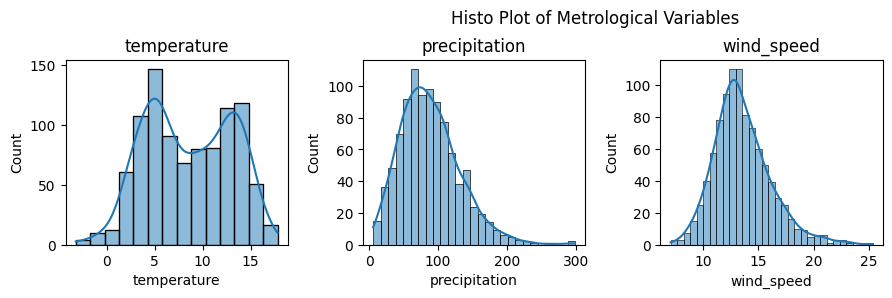

In [20]:
plt.figure(figsize=(12, 10))
numeric_cols = meteorological_cols
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(monthly_df[col], kde=True)
    plt.title(col)
plt.suptitle("Histo Plot of Metrological Variables")
plt.tight_layout()
plt.show()

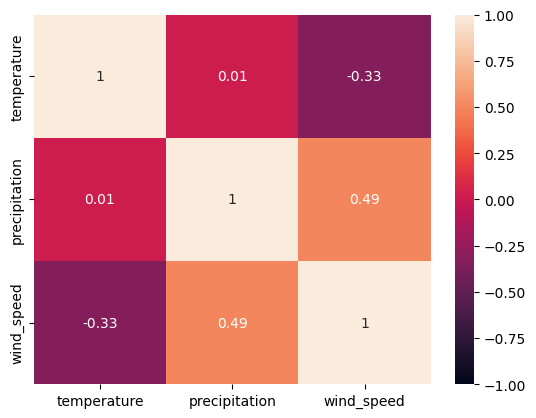

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
heatmap= sns.heatmap(monthly_df.corr(), vmin=-1, vmax=1, annot=True)

Is it ok to have correlation more than 0.5 between metrological data and use it in ML modles?
All variables are low correlated except perception and temperature are moderately correlated which should be fine.


**Line chart of tempreature accrous the years**

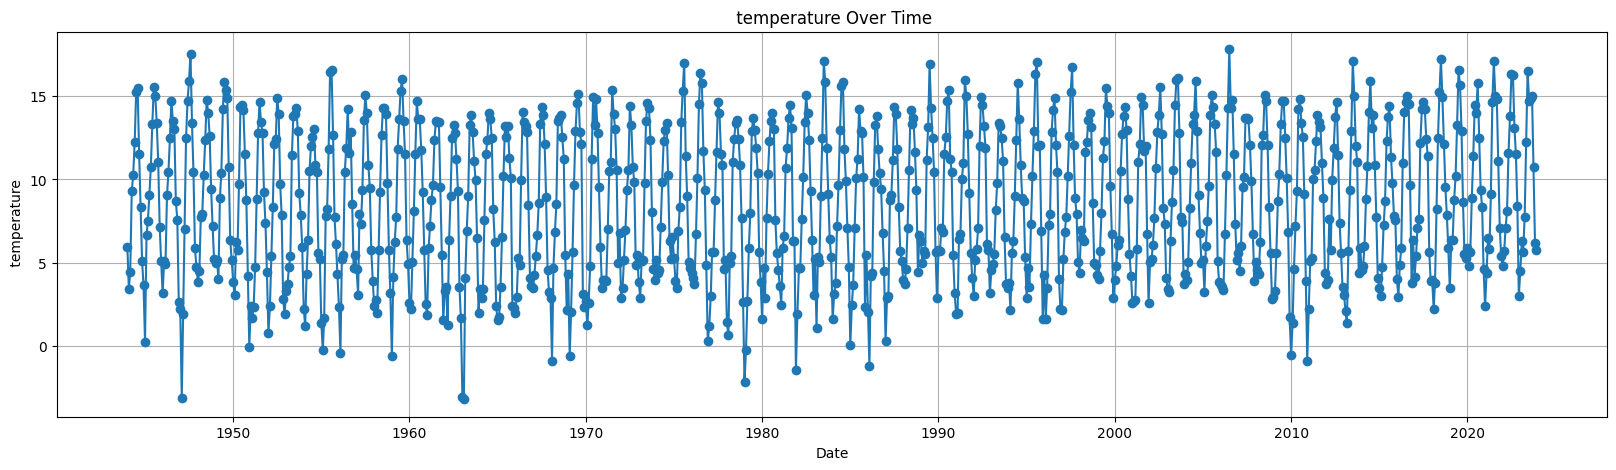

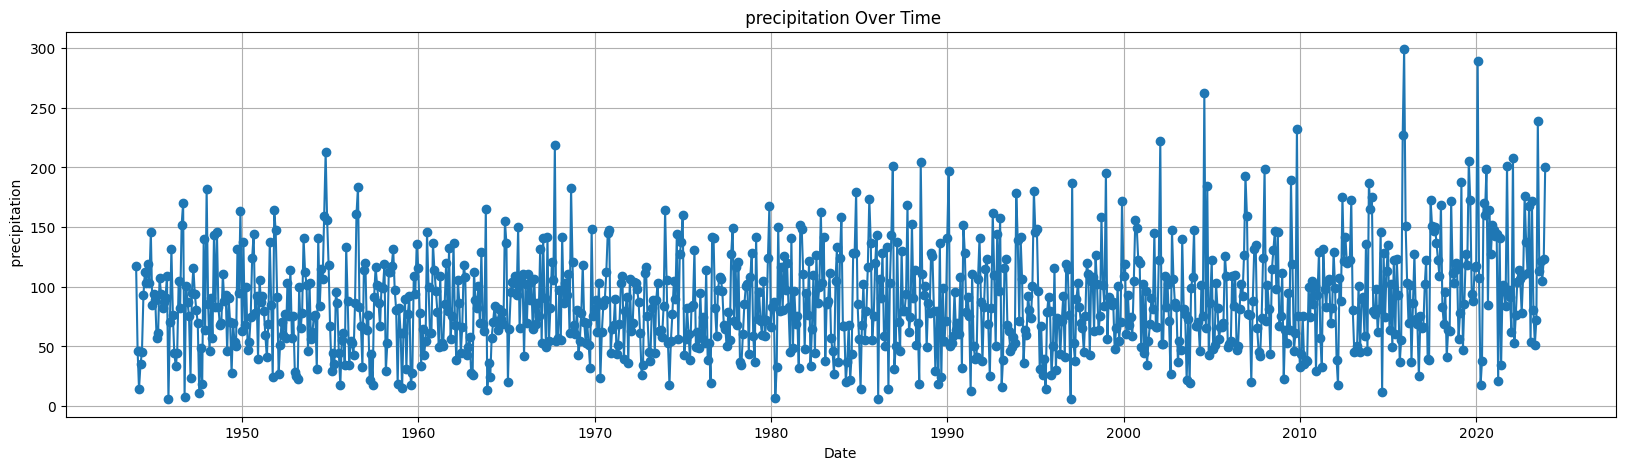

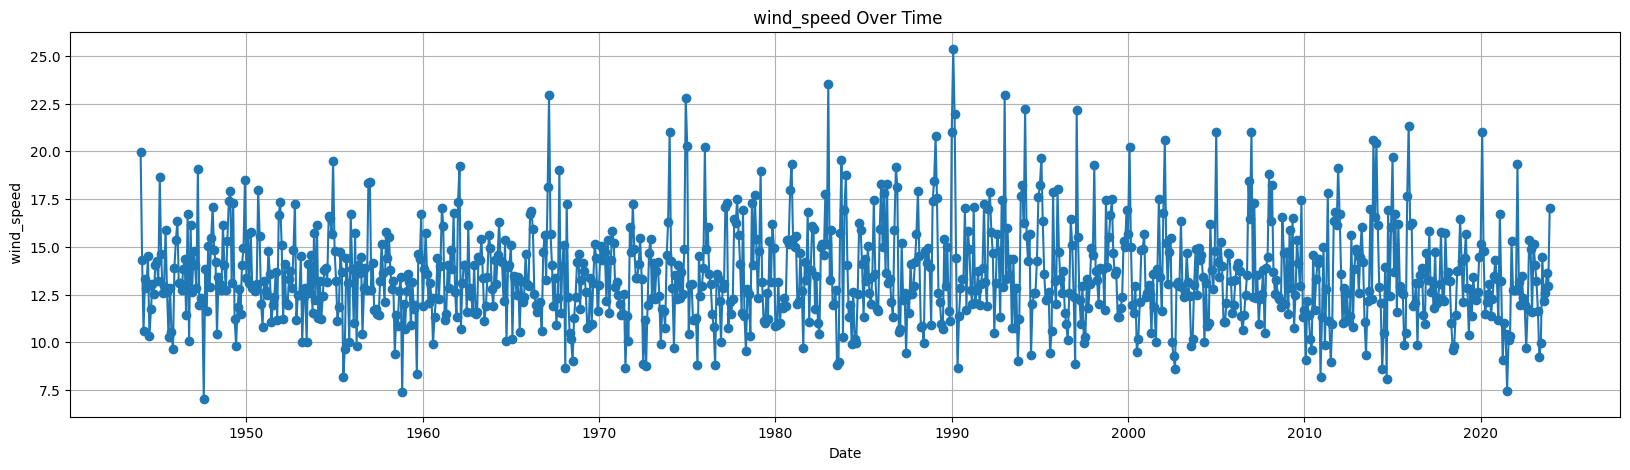

In [29]:
for i, col in enumerate(meteorological_cols):
  plt.figure(figsize=(20,5))
  plt.plot(monthly_df.index.to_timestamp(), monthly_df[col], marker='o', linestyle='-')
  plt.xlabel('Date')
  plt.ylabel(f" {col}")
  plt.title(f" {col} Over Time")
  plt.grid(True)

plt.show()